# Clustering with K-Means and DBSCAN
**Dataset:** Iris  |  **Tools:** scikit-learn, pandas, matplotlib, seaborn

---
## Table of Contents
1. [Part A — Data Exploration](#part-a)
2. [Part B — K-Means Clustering](#part-b)
3. [Part C — DBSCAN Clustering](#part-c)
4. [Part D — Reflection](#part-d)


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, confusion_matrix, silhouette_score
from sklearn.neighbors import NearestNeighbors
from scipy.optimize import linear_sum_assignment

sns.set_theme(style='whitegrid', palette='muted')
SEED = 42


## Part A — Data Exploration <a id='part-a'></a>

The Iris dataset has 150 samples, 4 features (sepal/petal length and width in cm), and 3 balanced classes of 50 samples each.


In [ ]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
df['target']  = iris.target

print(f'Shape: {df.shape}')
print(df['species'].value_counts().to_string())
df.head(10)


Shape: (150, 6)
species
setosa        50
versicolor    50
virginica     50


In [ ]:
df.describe().round(2)


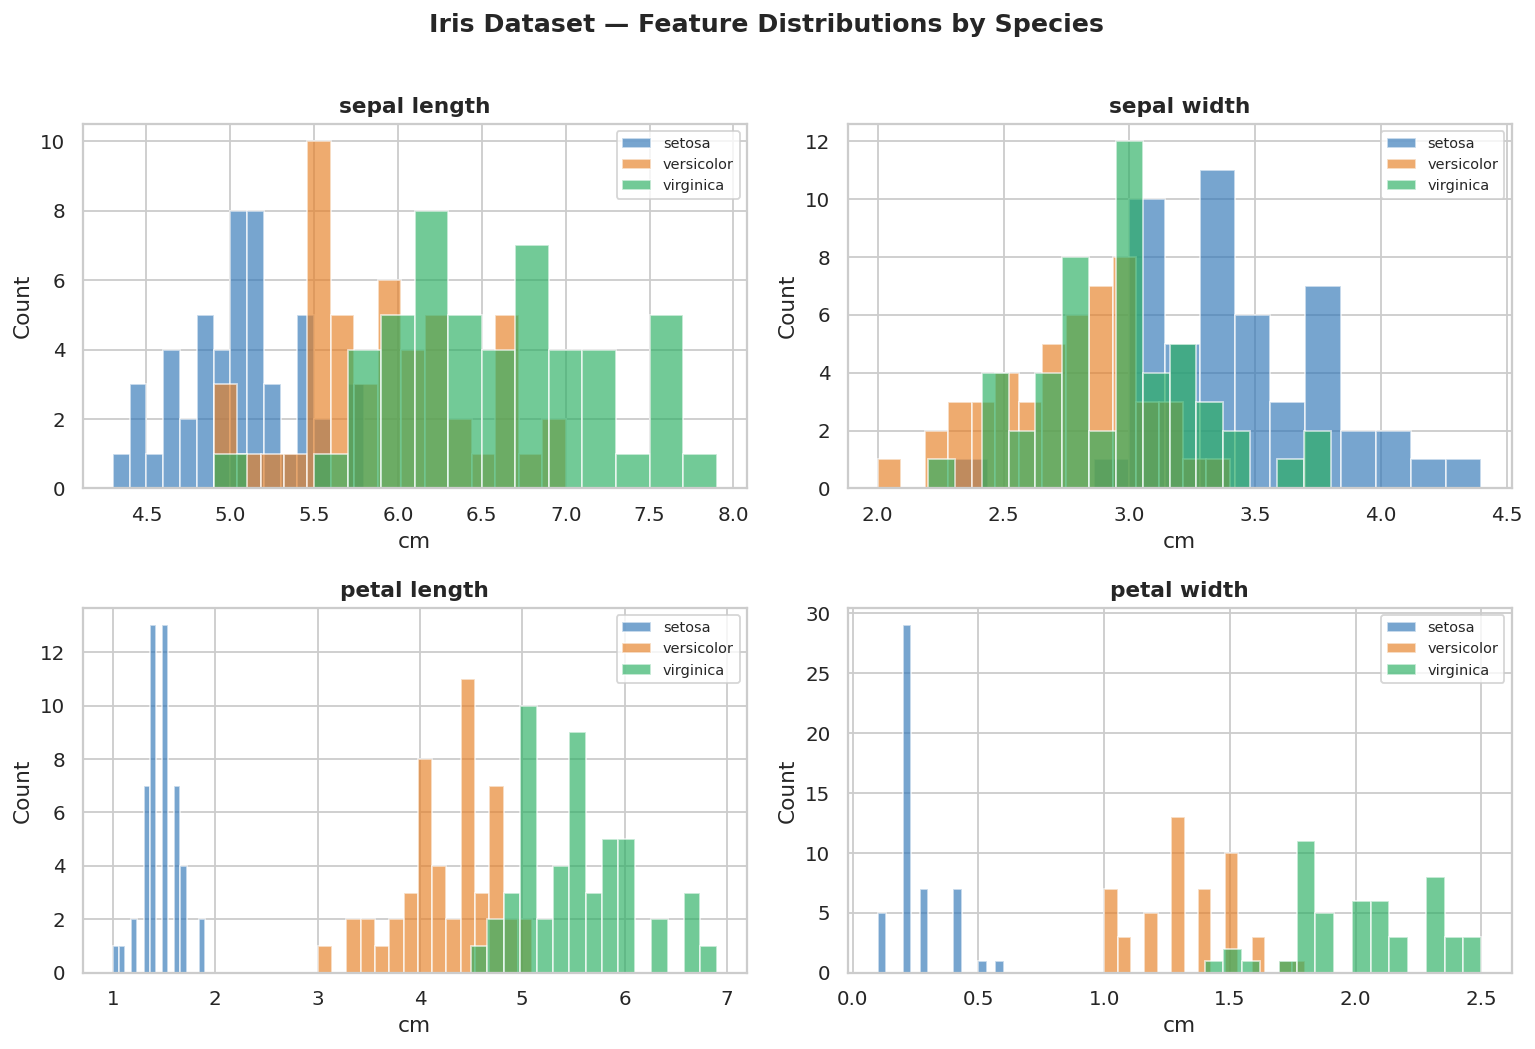

In [ ]:
colors = {'setosa': '#2E75B6', 'versicolor': '#E67E22', 'virginica': '#27AE60'}
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Distributions by Species', fontsize=14, fontweight='bold')
for ax, col in zip(axes.flat, iris.feature_names):
    for sp in iris.target_names:
        ax.hist(df[df['species']==sp][col], bins=15, alpha=0.65,
                label=sp, color=colors[sp], edgecolor='white')
    ax.set_title(col.replace(' (cm)',''), fontweight='bold')
    ax.set_xlabel('cm'); ax.set_ylabel('Count'); ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


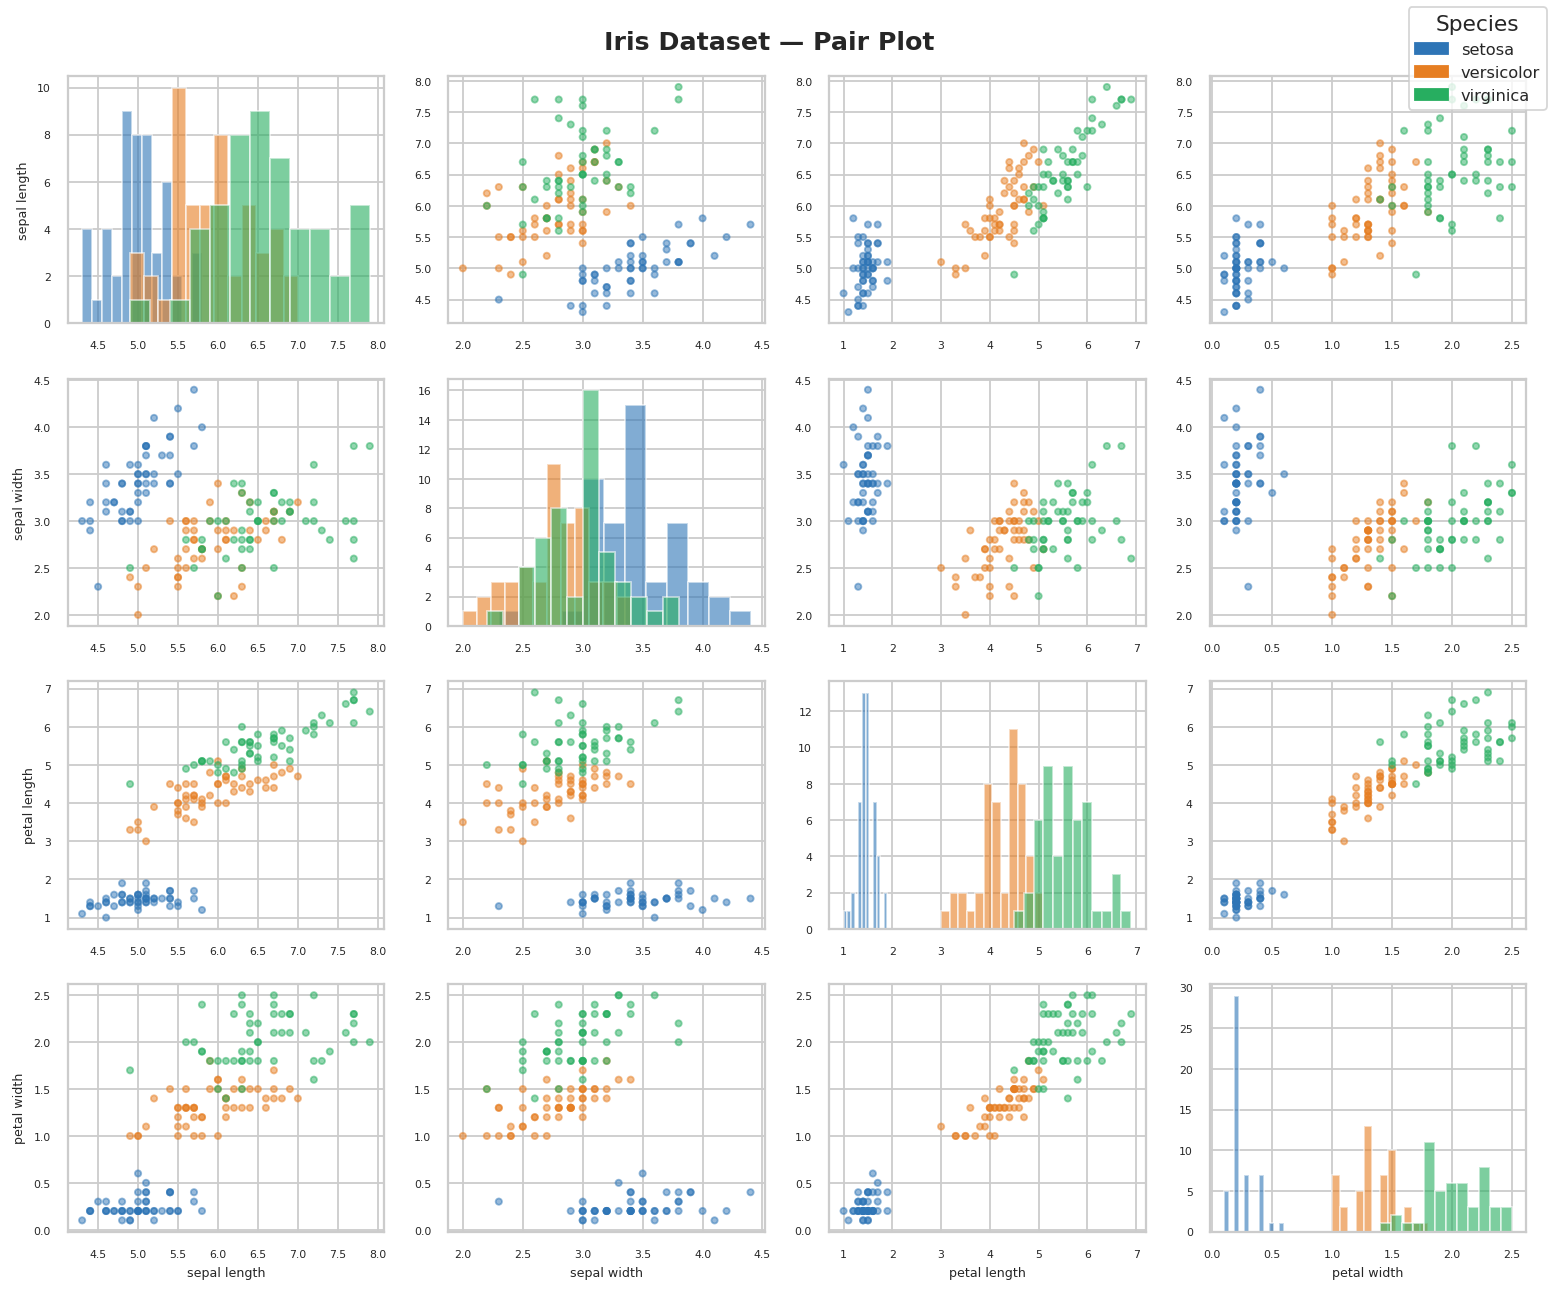

In [ ]:
n = len(iris.feature_names)
color_list = [colors[s] for s in df['species']]
fig, axes = plt.subplots(n, n, figsize=(12, 10))
fig.suptitle('Pair Plot', fontsize=14, fontweight='bold')
for i, j in product(range(n), range(n)):
    ax = axes[i, j]
    if i == j:
        for sp in iris.target_names:
            ax.hist(df[iris.feature_names[i]][df['species']==sp],
                    bins=12, alpha=0.6, color=colors[sp], edgecolor='white')
    else:
        ax.scatter(df[iris.feature_names[j]], df[iris.feature_names[i]],
                   c=color_list, alpha=0.5, s=12)
    if i == n-1: ax.set_xlabel(iris.feature_names[j].replace(' (cm)',''), fontsize=7)
    if j == 0:   ax.set_ylabel(iris.feature_names[i].replace(' (cm)',''), fontsize=7)
    ax.tick_params(labelsize=6)
from matplotlib.patches import Patch
handles = [Patch(color=colors[sp], label=sp) for sp in iris.target_names]
fig.legend(handles=handles, loc='upper right', fontsize=9, title='Species')
plt.tight_layout()
plt.show()


**Observations:**
- Setosa is clearly separated from the other two species, especially in petal length and width.
- Versicolor and Virginica overlap, making them harder to distinguish.
- Petal length and petal width are strongly correlated — the pair plot shows a tight linear relationship between them.
- Sepal width has the most overlap across all three species and is the least useful feature on its own.


---
## Part B — K-Means Clustering <a id='part-b'></a>

Features are scaled with `StandardScaler` before clustering. PCA (2 components) is used only for visualization — clustering runs on the full 4D scaled space.


In [ ]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(iris.data)

pca   = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)
print(f'Explained variance: {pca.explained_variance_ratio_.round(3)}  total={pca.explained_variance_ratio_.sum():.1%}')


Explained variance: [0.73  0.229]  total=95.8%


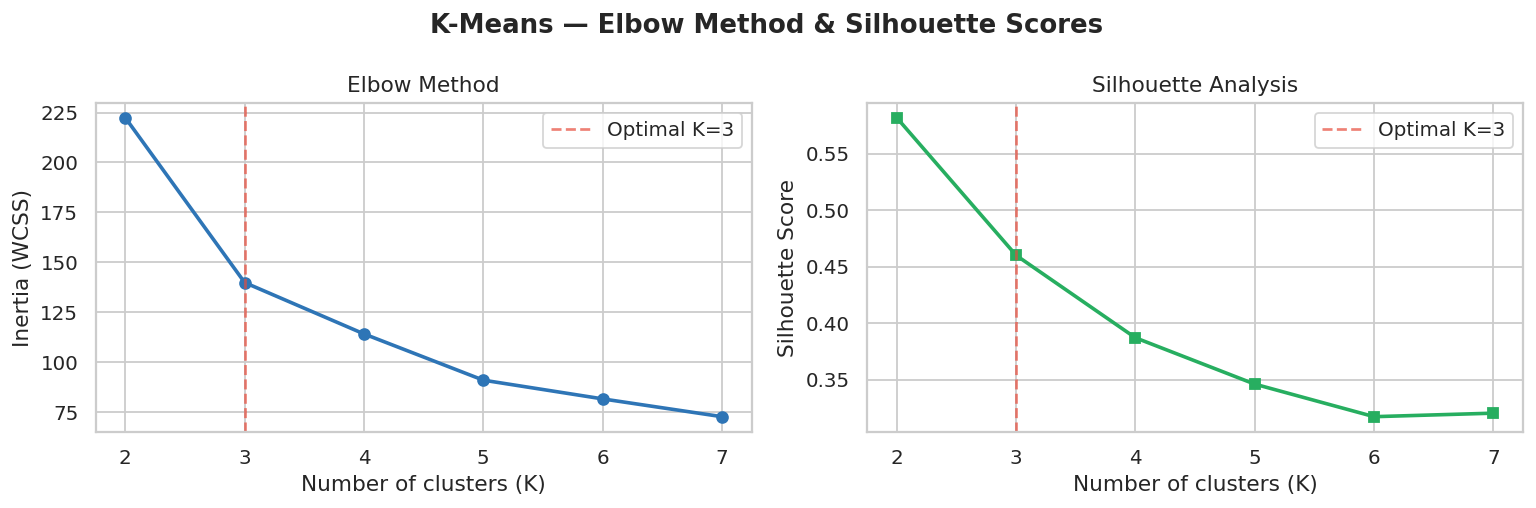

In [ ]:
k_range = range(2, 8)
inertias, sil_scores = [], []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertias, 'o-', color='#2E75B6', lw=2)
axes[0].axvline(3, color='#E74C3C', ls='--', alpha=0.7, label='K=3')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method'); axes[0].legend()
axes[1].plot(k_range, sil_scores, 's-', color='#27AE60', lw=2)
axes[1].axvline(3, color='#E74C3C', ls='--', alpha=0.7, label='K=3')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Analysis'); axes[1].legend()
plt.tight_layout()
plt.show()


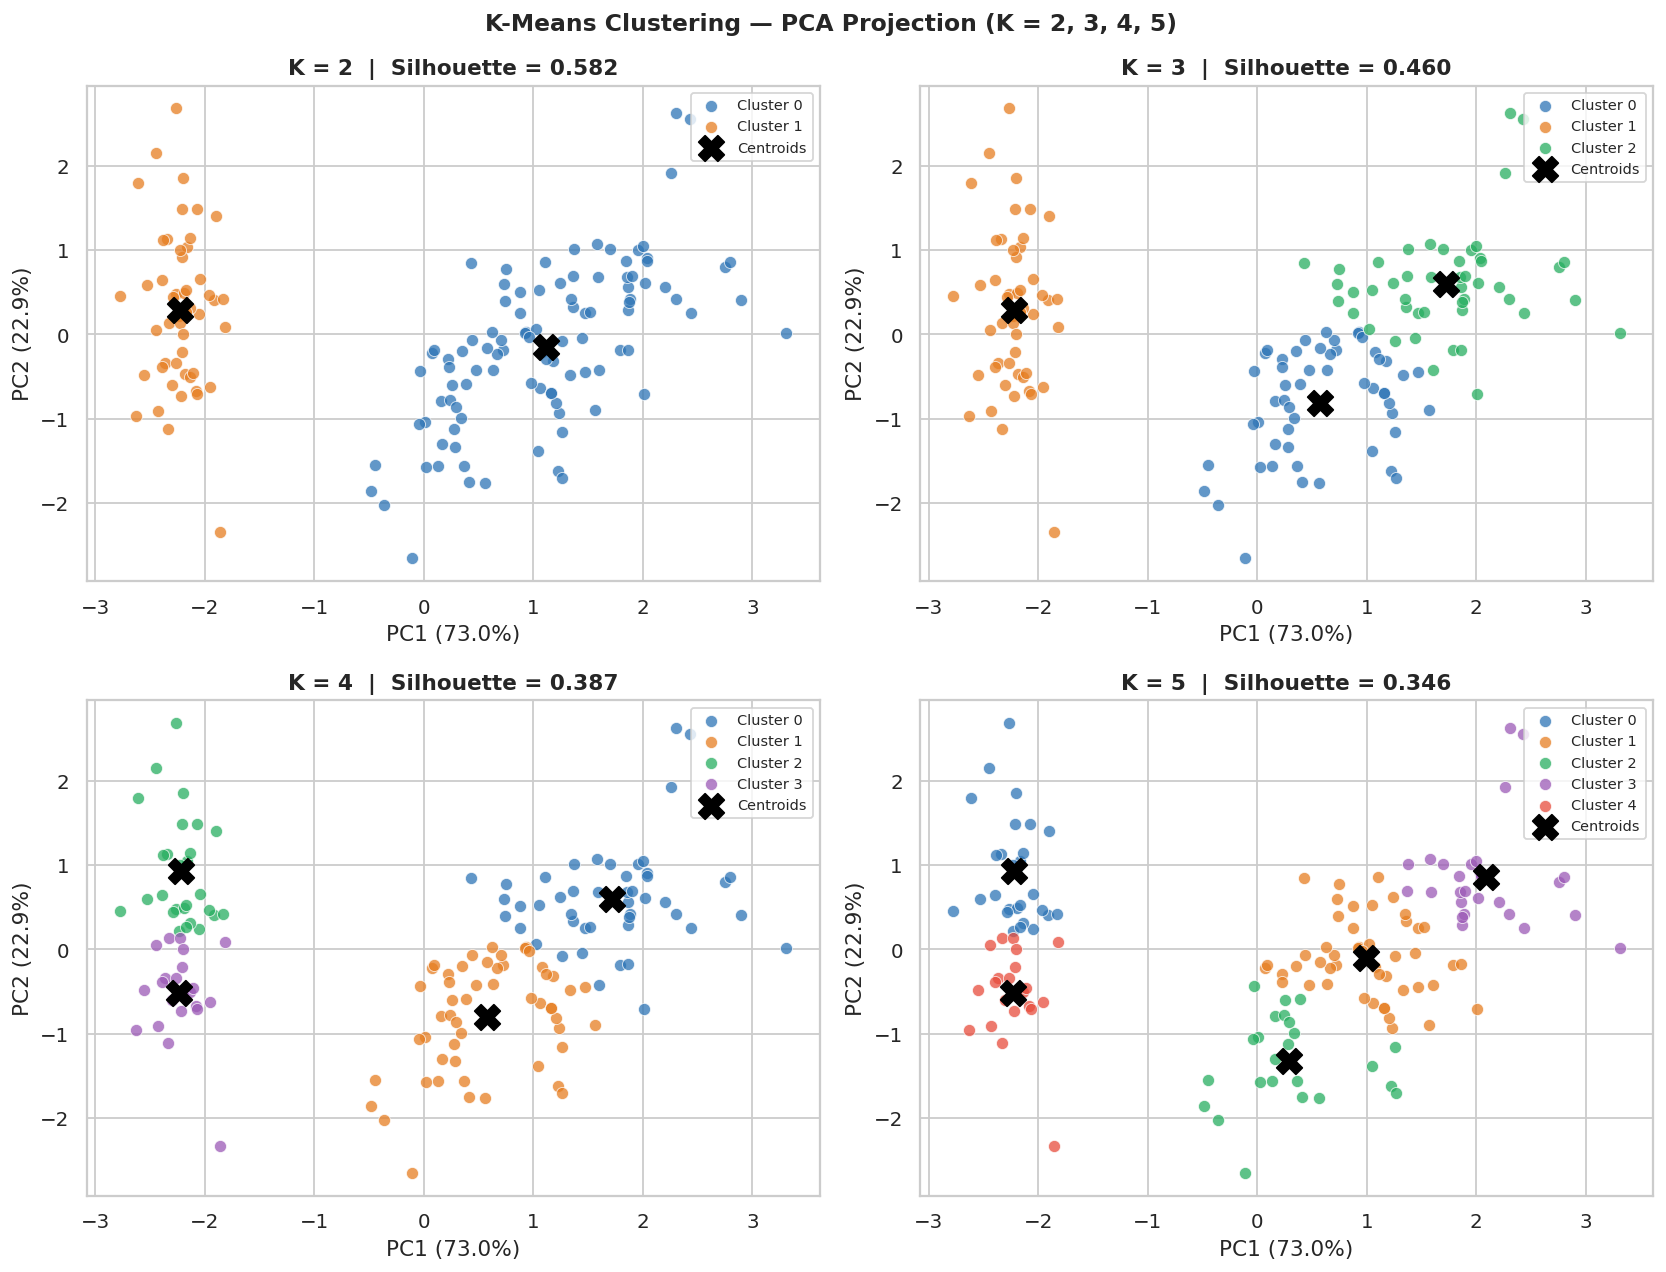

In [ ]:
cmap_list = ['#2E75B6','#E67E22','#27AE60','#9B59B6','#E74C3C','#1ABC9C']
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('K-Means — PCA Projection (K = 2, 3, 4, 5)', fontweight='bold', fontsize=13)

for ax, k in zip(axes.flat, [2, 3, 4, 5]):
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_scaled)
    centers_pca = pca.transform(km.cluster_centers_)
    sil = silhouette_score(X_scaled, labels)
    for c in range(k):
        mask = labels == c
        ax.scatter(X_pca[mask,0], X_pca[mask,1], s=45, alpha=0.75,
                   color=cmap_list[c], label=f'Cluster {c}', edgecolors='white', lw=0.5)
    ax.scatter(centers_pca[:,0], centers_pca[:,1], s=200, c='black',
               marker='X', zorder=5, label='Centroids')
    ax.set_title(f'K={k}  |  Silhouette={sil:.3f}', fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


ARI (K=3 vs true labels): 0.6201


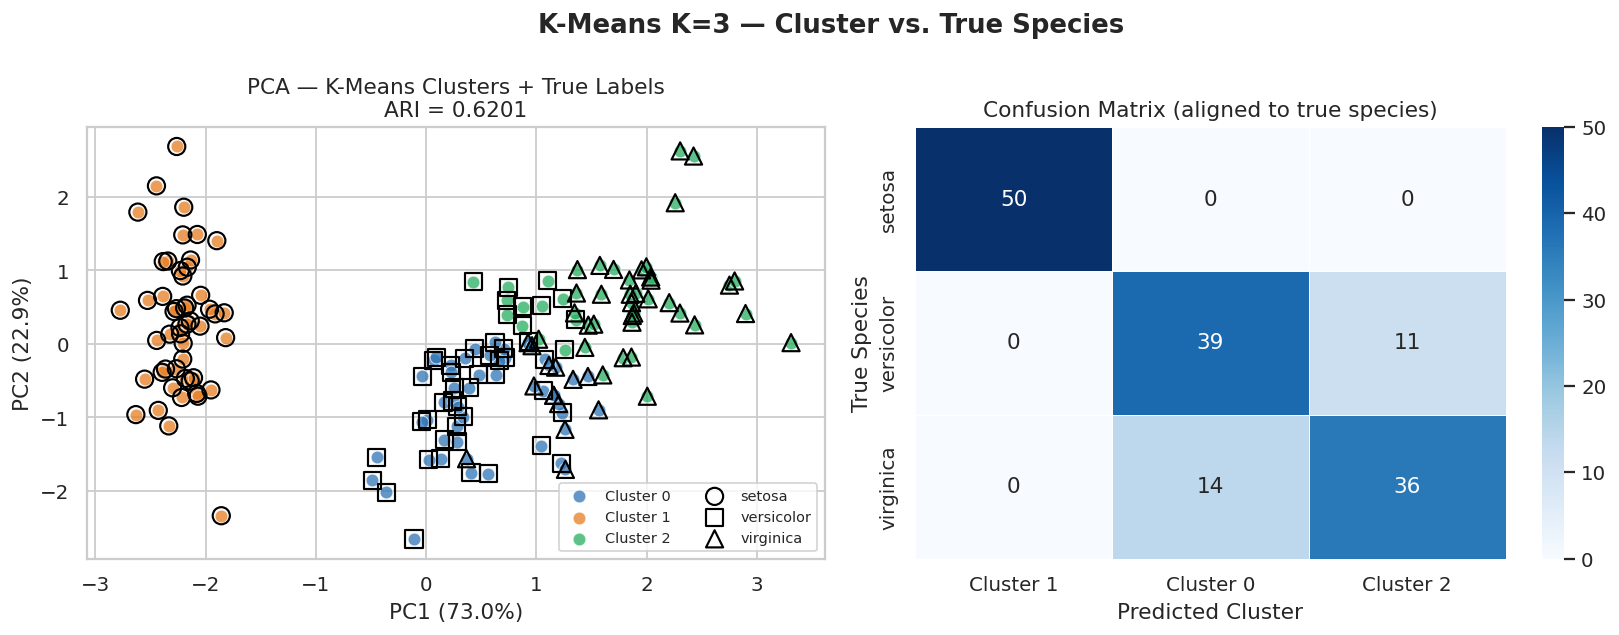

In [ ]:
km3 = KMeans(n_clusters=3, random_state=SEED, n_init=10)
km3_labels = km3.fit_predict(X_scaled)
ari = adjusted_rand_score(iris.target, km3_labels)
print(f'ARI (K=3 vs true labels): {ari:.4f}')

cm_raw = confusion_matrix(iris.target, km3_labels)
row_ind, col_ind = linear_sum_assignment(-cm_raw)
cm_aligned = cm_raw[:, col_ind]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for c in range(3):
    mask = km3_labels == c
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1], s=50, alpha=0.75,
                    color=cmap_list[c], label=f'Cluster {c}', edgecolors='white', lw=0.5)
for t, marker in enumerate(['o','s','^']):
    mask = iris.target == t
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1], s=90, facecolors='none',
                    edgecolors='black', lw=1.2, marker=marker, label=iris.target_names[t])
axes[0].set_title(f'Clusters (fill) + True Labels (outline) — ARI={ari:.4f}')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8, ncol=2)

sns.heatmap(cm_aligned, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=[f'Cluster {i}' for i in col_ind],
            yticklabels=iris.target_names, linewidths=0.5)
axes[1].set_title('Confusion Matrix')
axes[1].set_ylabel('True Species'); axes[1].set_xlabel('Predicted Cluster')
plt.tight_layout()
plt.show()


**Interpretation:**
- Both the elbow and silhouette methods point to K=3 as the best choice, matching the actual number of species.
- K-Means correctly separates Setosa (ARI contribution near perfect) but confuses some Versicolor and Virginica samples due to their overlapping region.
- ARI of 0.62 shows good but imperfect alignment with ground truth.
- Increasing K beyond 3 splits Virginica unnecessarily — silhouette drops, clusters become less meaningful.
- K=2 cleanly isolates Setosa but lumps Versicolor and Virginica together.
- K-Means assumes spherical, equally sized clusters, which doesn't perfectly match the elongated Versicolor/Virginica boundary — that's the main source of error.


---
## Part C — DBSCAN Clustering <a id='part-c'></a>

DBSCAN groups points by local density and marks low-density points as noise (label = -1). The k-distance plot helps pick a good `eps` value by finding the 'knee' in the curve.


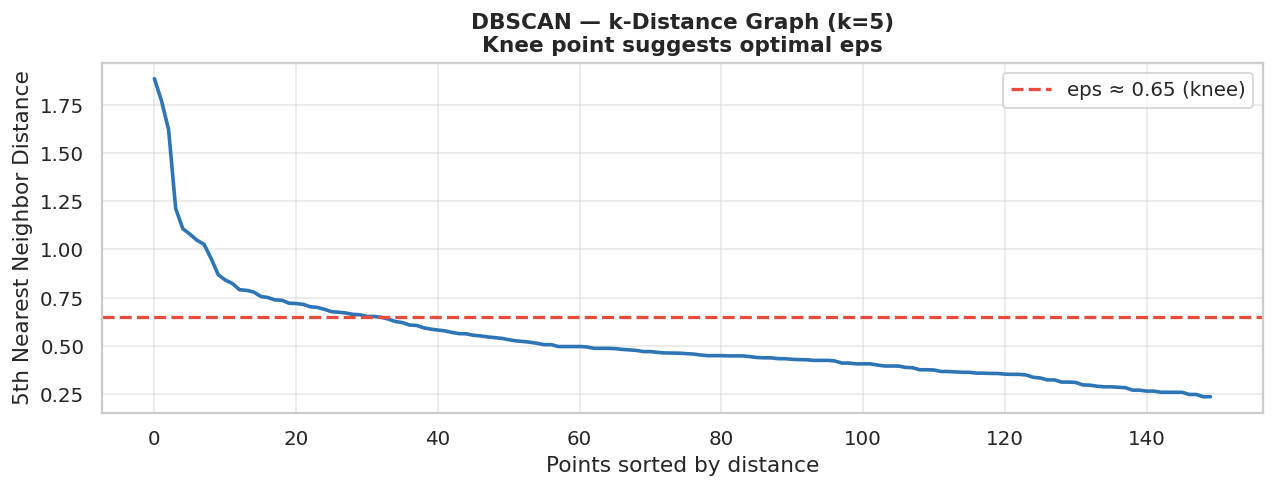

In [ ]:
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_dist = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_dist, color='#2E75B6', lw=2)
ax.axhline(0.65, color='#E74C3C', ls='--', lw=1.8, label='eps ≈ 0.65')
ax.set_title('k-Distance Graph (k=5)', fontweight='bold')
ax.set_xlabel('Points sorted by distance'); ax.set_ylabel('5th Nearest Neighbor Distance')
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


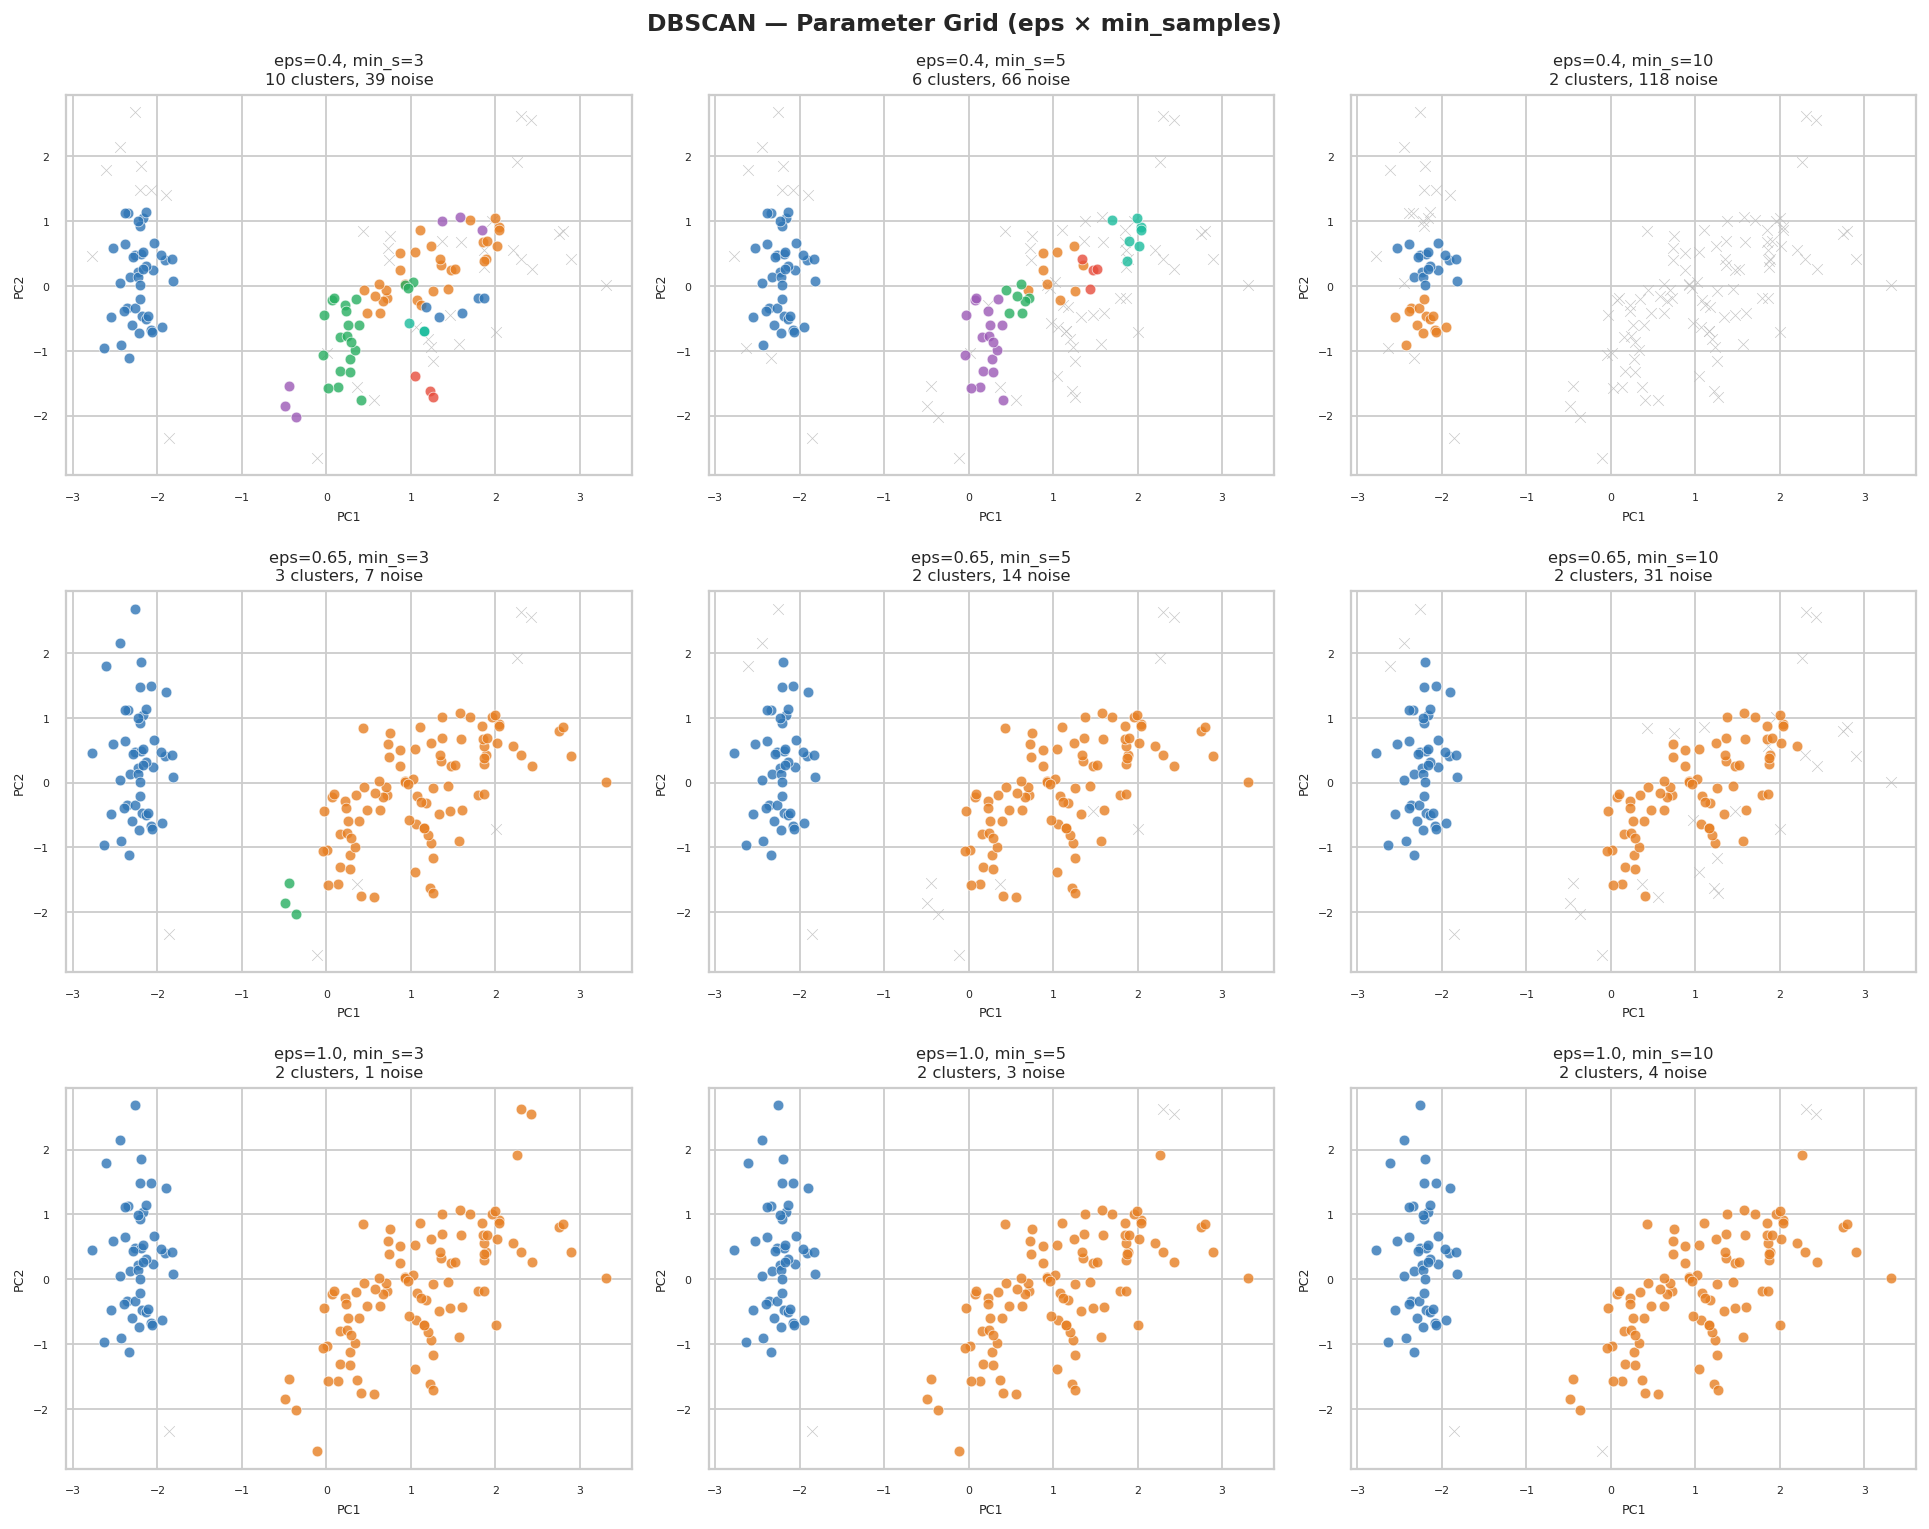

In [ ]:
eps_vals = [0.4, 0.65, 1.0]
ms_vals  = [3, 5, 10]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('DBSCAN — Parameter Grid (eps × min_samples)', fontweight='bold', fontsize=13)

for i, eps in enumerate(eps_vals):
    for j, ms in enumerate(ms_vals):
        ax = axes[i, j]
        db = DBSCAN(eps=eps, min_samples=ms).fit(X_scaled)
        lbls = db.labels_
        n_cl = len(set(lbls)) - (1 if -1 in lbls else 0)
        n_n  = np.sum(lbls == -1)
        palette = {-1: '#BBBBBB'}
        for idx, c in enumerate([u for u in sorted(set(lbls)) if u != -1]):
            palette[c] = cmap_list[idx % len(cmap_list)]
        for lbl in sorted(set(lbls)):
            mask = lbls == lbl
            ax.scatter(X_pca[mask,0], X_pca[mask,1], s=35, c=palette[lbl],
                       marker='x' if lbl==-1 else 'o', alpha=0.8,
                       edgecolors='white' if lbl!=-1 else 'none', lw=0.4)
        ax.set_title(f'eps={eps}, min_s={ms} | {n_cl} cl, {n_n} noise', fontsize=9)
        ax.tick_params(labelsize=6)

plt.tight_layout()
plt.show()


Clusters: 2  |  Noise points: 14 (9.3%)
ARI (excl. noise): 0.5734


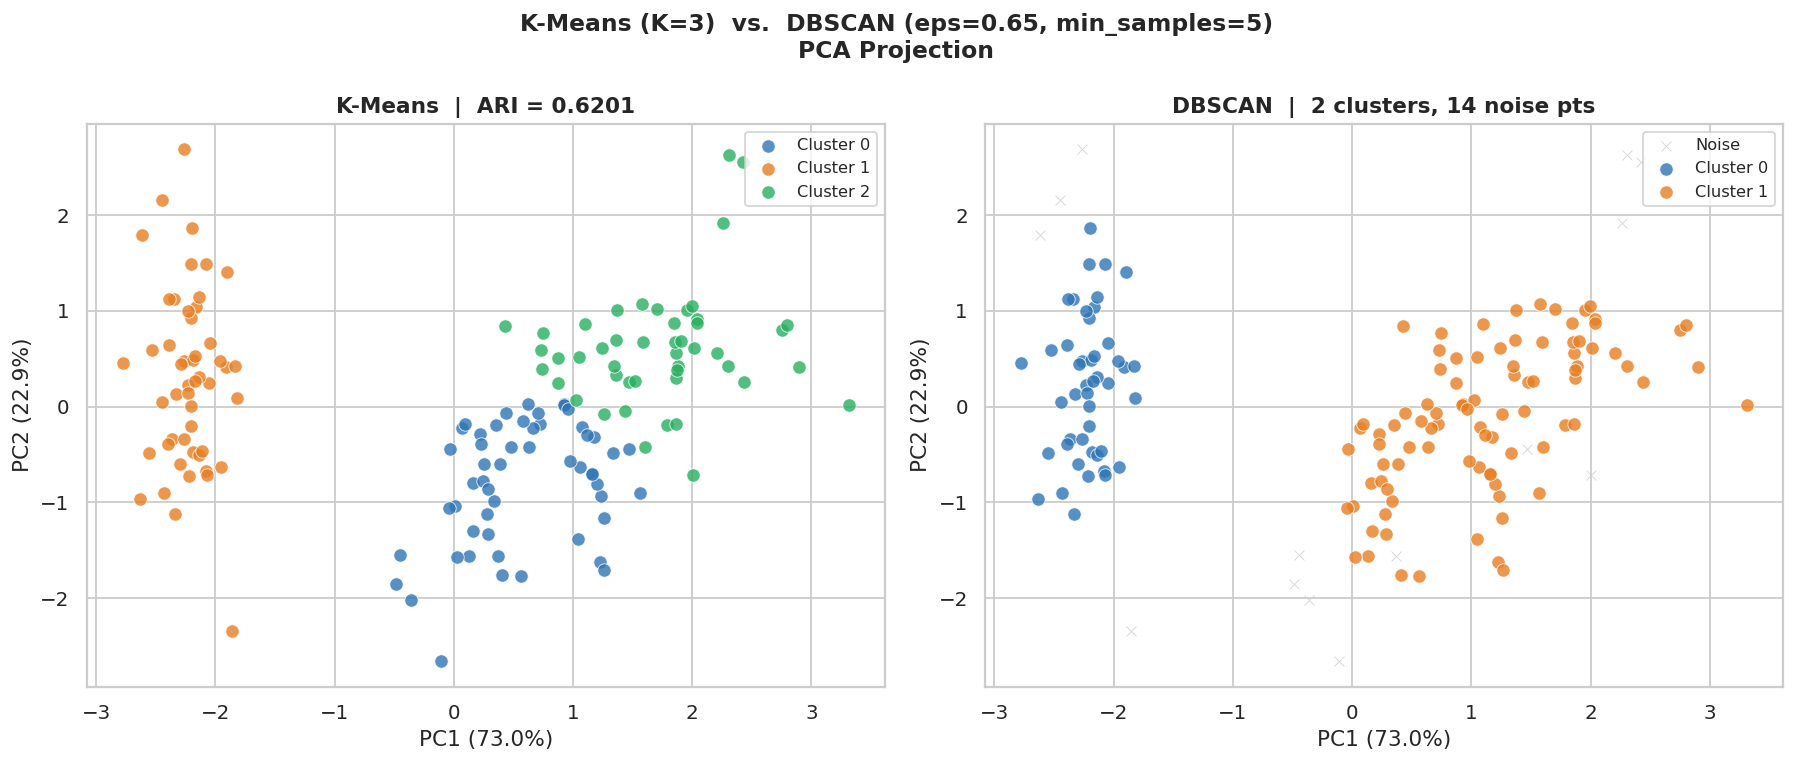

In [ ]:
db_best   = DBSCAN(eps=0.65, min_samples=5).fit(X_scaled)
db_labels = db_best.labels_
n_clusters_db = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise_db    = np.sum(db_labels == -1)
print(f'Clusters: {n_clusters_db}  |  Noise points: {n_noise_db} ({n_noise_db/len(db_labels):.1%})')

mask_valid = db_labels != -1
ari_db = adjusted_rand_score(iris.target[mask_valid], db_labels[mask_valid])
print(f'ARI (excl. noise): {ari_db:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('K-Means (K=3) vs DBSCAN (eps=0.65, min_samples=5)', fontweight='bold', fontsize=13)

for c in range(3):
    mask = km3_labels == c
    axes[0].scatter(X_pca[mask,0], X_pca[mask,1], s=55, alpha=0.8,
                    color=cmap_list[c], label=f'Cluster {c}', edgecolors='white', lw=0.5)
axes[0].set_title(f'K-Means  |  ARI={ari:.4f}', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].legend(fontsize=9)

palette_db = {-1: '#CCCCCC'}
for idx, c in enumerate(sorted(set(db_labels)-{-1})):
    palette_db[c] = cmap_list[idx % len(cmap_list)]
for lbl in sorted(set(db_labels)):
    mask = db_labels == lbl
    axes[1].scatter(X_pca[mask,0], X_pca[mask,1],
                    s=55 if lbl!=-1 else 30, alpha=0.8, color=palette_db[lbl],
                    marker='o' if lbl!=-1 else 'x',
                    label='Noise' if lbl==-1 else f'Cluster {lbl}',
                    edgecolors='white' if lbl!=-1 else 'none', lw=0.5)
axes[1].set_title(f'DBSCAN  |  ARI={ari_db:.4f}', fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2'); axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()


**Interpretation:**
- eps=0.65, min_samples=5 gave the best balance — 2 clusters with 14 noise points (9.3%).
- DBSCAN cleanly isolated Setosa but merged Versicolor and Virginica into one cluster. Their density is too similar for DBSCAN to separate them at any eps setting.
- Smaller eps values (0.4) produced more clusters but also flagged too many points as noise — too strict.
- Larger eps (1.0) collapsed everything into a single cluster — too lenient.
- The 14 noise points represent borderline samples that sit between clusters.

**K-Means vs DBSCAN:**

| | K-Means (K=3) | DBSCAN (eps=0.65, min_s=5) |
|---|---|---|
| Clusters found | 3 | 2 |
| ARI | **0.6201** | 0.5734 |
| Handles noise | No | Yes (14 pts flagged) |
| Assumes cluster shape | Spherical | Arbitrary |
| Requires K upfront | Yes | No |

K-Means performs better here because the Iris clusters are roughly spherical and similarly sized. DBSCAN would have the advantage on data with irregular shapes or meaningful outliers.


---
## Part D — Reflection <a id='part-d'></a>

### Real-World Application
One strong use case for clustering is **hospital patient stratification**. By clustering patients based on lab results, vitals, and medication history, hospitals can identify groups that respond differently to treatments — enabling more targeted care. DBSCAN is especially useful here because it can flag anomalous patients (noise points) who don't fit typical profiles, which can signal rare conditions or data entry errors.

### Ethical Considerations
- **Proxy bias:** Features like zip code or income can act as proxies for race or ethnicity, so clusters may reflect systemic inequalities rather than meaningful patterns.
- **Labeling risk:** Assigning a label like "high-risk" to a cluster affects real people. If the cluster is based on biased data, those labels can unfairly restrict access to services or opportunities.
- **Feedback loops:** When clustering outputs drive decisions — who gets a loan, who gets flagged for extra screening — those decisions generate new data that reinforces the original cluster structure over time.
- **Lack of accountability:** Unsupervised learning has no ground truth to validate against. Clusters can look convincing but be entirely arbitrary depending on preprocessing choices.
- **Mitigation:** Always audit feature selection for disparate impact, validate findings with domain experts, and avoid using cluster labels in high-stakes decisions without additional review.
